<a href="https://colab.research.google.com/github/marlon-2006/Examen-Introduccion-Sistemas-Informacion/blob/main/ExamenB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Dataset cargado correctamente")
print(f"Número de registros: {len(df)}")


# KPI 1: TASA DE ROTACIÓN DE PERSONAL

print("\n" + "="*70)
print("KPI 1: TASA DE ROTACIÓN DE PERSONAL")
print("="*70)

attrition_rate = (df['Attrition'] == 'Yes').mean() * 100

print(f"Tasa de Rotación = {attrition_rate:.2f}%")

# KPI 2: INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO

print("\n" + "="*70)
print("KPI 2: INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO")
print("="*70)

income_department = (
    df.groupby('Department')['MonthlyIncome']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

print(income_department)


# KPI 3: WORK-LIFE BALANCE PROMEDIO POR CARGO

print("\n" + "="*70)
print("KPI 3: WORK-LIFE BALANCE PROMEDIO POR CARGO")
print("="*70)

wlb_role = (
    df.groupby('JobRole')['WorkLifeBalance']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

print(wlb_role)

# KPI 4: BRECHA DE ESTANCAMIENTO LABORAL

print("\n" + "="*70)
print("KPI 4: BRECHA DE ESTANCAMIENTO LABORAL")
print("="*70)

df['Brecha_Estancamiento'] = (
    df['YearsInCurrentRole']
    - df['YearsSinceLastPromotion']
)

brecha_promedio = df['Brecha_Estancamiento'].mean()

print(f"Brecha Promedio General = {brecha_promedio:.2f} años")

print("\nBrecha por Cargo:")

brecha_cargo = (
    df.groupby('JobRole')['Brecha_Estancamiento']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

print(brecha_cargo)


colores_kpi2 = ['#2196F3', '#64B5F6', '#0D47A1']
colores_kpi3 = ['#4CAF50', '#81C784', '#388E3C',
                '#A5D6A7', '#1B5E20', '#66BB6A',
                '#2E7D32', '#C8E6C9', '#43A047']
colores_kpi4 = ['#FF6F00', '#FFA726', '#E65100',
                '#FFB74D', '#BF360C', '#FF8F00',
                '#FFCC80', '#E64A19', '#FF7043']






Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente
Número de registros: 1470

KPI 1: TASA DE ROTACIÓN DE PERSONAL
Tasa de Rotación = 16.12%

KPI 2: INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO
Department
Sales                     6959.17
Human Resources           6654.51
Research & Development    6281.25
Name: MonthlyIncome, dtype: float64

KPI 3: WORK-LIFE BALANCE PROMEDIO POR CARGO
JobRole
Human Resources              2.92
Sales Representative         2.89
Research Director            2.86
Sales Executive              2.80
Manager                      2.77
Manufacturing Director       2.77
Laboratory Technician        2.72
Healthcare Representative    2.70
Research Scientist           2.68
Name: WorkLifeBalance, dtype: float64

KPI 4: BRECHA DE ESTANCAMIENTO LABORAL
Brecha Promedio General = 2.04 años

Brecha por Cargo:
JobRole
Research Director            3.10
Manufacturing Direc

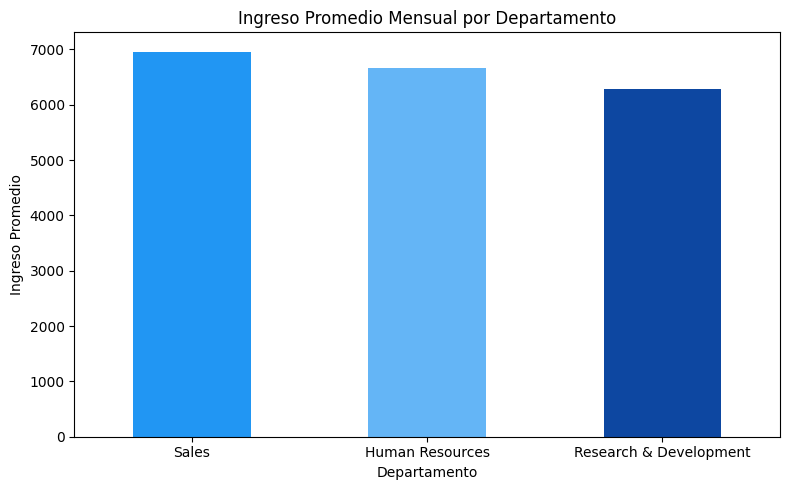

In [22]:
# GRAFICO KPI2

plt.figure(figsize=(8, 5))
income_department.plot(kind='bar', color=colores_kpi2[:len(income_department)])
plt.title('Ingreso Promedio Mensual por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Ingreso Promedio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

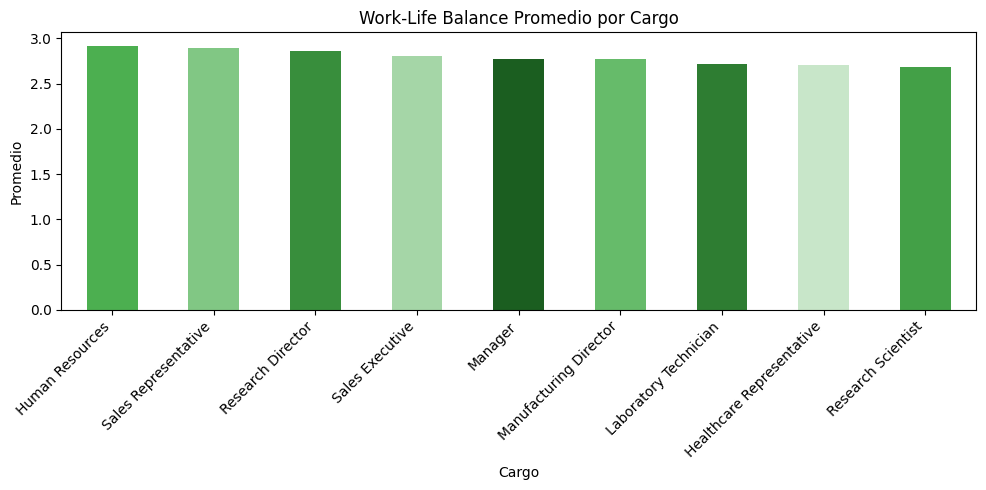

In [23]:
# GRAFICO KPI 3

plt.figure(figsize=(10, 5))
wlb_role.plot(kind='bar', color=colores_kpi3[:len(wlb_role)])
plt.title('Work-Life Balance Promedio por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

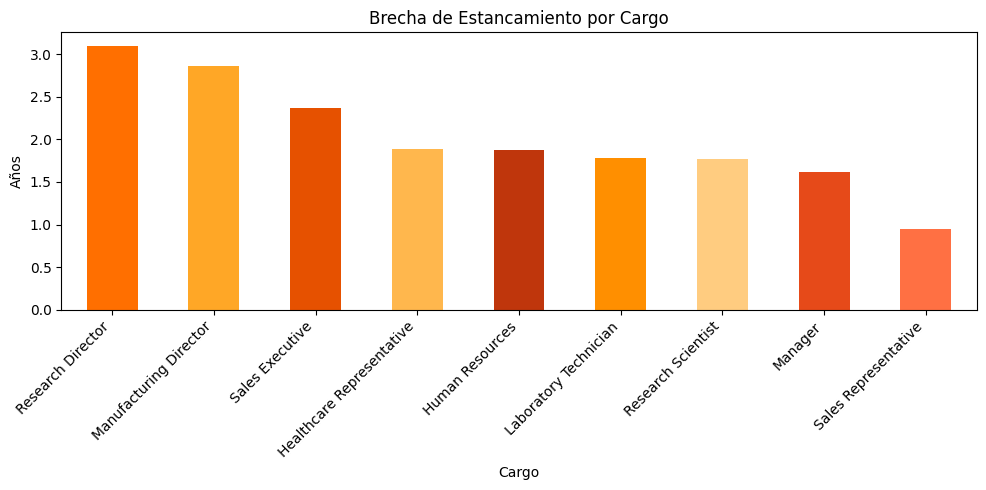

In [24]:
# GRÁFICO KPI 4

plt.figure(figsize=(10, 5))
brecha_cargo.plot(kind='bar', color=colores_kpi4[:len(brecha_cargo)])
plt.title('Brecha de Estancamiento por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Años')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




# Reporte de KPIs

## KPI 1: Tasa de Rotación de Personal (Attrition Rate)

**Valor obtenido:** 16.2 %

**Interpretación de negocio:**
La tasa de rotación indica el porcentaje de empleados que abandonaron la organización respecto al total de colaboradores registrados. Un valor elevado puede reflejar dificultades en la retención del talento y generar mayores costos de contratación y capacitación.

## KPI 2: Ingreso Promedio Mensual por Departamento

**Valores obtenidos:**

* Human Resources: $6654.51

* Research & Development: $6281.25

* Sales: $6959.17

**Interpretación de negocio:**
Este indicador permite comparar las estructuras salariales entre los distintos departamentos de la empresa. Las diferencias observadas pueden explicarse por las responsabilidades, especialización y demanda de talento de cada área funcional.

## KPI 3: Índice de Balance Vida–Trabajo Promedio por Cargo

**Valores obtenidos:**

- Human Resources              2.92

- Sales Representative         2.89

- Research Director            2.86

- Sales Executive              2.80

- Manager                      2.77

- Manufacturing Director       2.77

- Laboratory Technician        2.72

- Healthcare Representative    2.70

- Research Scientist           2.68

**Interpretación de negocio:**
El índice vida–trabajo ayuda a identificar los cargos con mejores o peores condiciones percibidas por los empleados. Los cargos con puntuaciones más bajas pueden presentar un mayor riesgo de agotamiento laboral y futura rotación de personal.


## KPI 4: Brecha de Estancamiento Laboral

**Valor promedio obtenido:**  2.04 años

**Interpretación de negocio:**
La brecha de estancamiento mide la diferencia entre los años que un empleado permanece en su puesto actual y los años transcurridos desde su última promoción. Valores elevados pueden indicar limitadas oportunidades de crecimiento profesional, afectando la motivación y el compromiso de los colaboradores.

## Conclusión

El análisis de los KPIs permite evaluar aspectos clave de la gestión del talento humano, incluyendo la retención de empleados, el tema salarial, el bienestar laboral y las oportunidades de desarrollo profesional. Estos KPIs nos ayudan a la toma de decisiones estratégicas para mejorar el desempeño de forma organizada.
